# Grad-CAM & Explicabilité visuelle

Visualisation des zones d'attention via Grad-CAM (Gradient-weighted Class Activation Maps) sur la couche `layer4` de ResNet18. Trois analyses :
1. **Grad-CAM par classe** - quelles régions le BNN regarde-t-il pour chaque type de tumeur ?
2. **CNN baseline vs BNN multimodal** - l'attention change-t-elle avec la tête bayésienne ?
3. **Incertitude spatiale (MC Grad-CAM)** - sur 50 passes Monte-Carlo, où l'attention varie-t-elle ?

**Prérequis :** `runs_cnn_baseline/best_final.pt` (notebook 01) et `runs_bnn_multimodal/best.pt` (notebook 03).

**Sortie :** `runs_gradcam/gradcam_per_class.png`, `gradcam_cnn_vs_bnn.png`, `gradcam_uncertainty.png`.

### Imports & seed

In [64]:
import os, random, glob
import numpy as np
import torch
import torch.nn as nn
import torchbnn as bnn
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cv2

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print(device)

mps


### Chemins & config

In [65]:
DATAROOT = "/Users/teodul/Documents/Memoire/Epic and CSCR hospital Dataset"
TESTDIR  = os.path.join(DATAROOT, "Test")
BNNCKPT  = "runs_bnn_multimodal/best.pt"
SAVEDIR  = "runs_gradcam"
os.makedirs(SAVEDIR, exist_ok=True)

IMGSIZE    = 224
MC_PASSES  = 50
CLASSES    = ["glioma", "meningioma", "notumor", "pituitary"]
NUM_CLASSES = 4
COLORS     = ["tomato", "steelblue", "seagreen", "darkorange"]

### Modèle BNN

In [66]:
class BNNMultimodalNet(nn.Module):
    def __init__(self, num_classes=4, clinical_dim=1,
                 prior_mu=0, prior_sigma=0.1):
        super().__init__()

        backbone    = models.resnet18(weights="IMAGENET1K_V1")
        backbone.fc = nn.Identity()
        self.cnn    = backbone

        for param in self.cnn.parameters():
            param.requires_grad = False

        self.clinical_mlp = nn.Sequential(
            nn.Linear(clinical_dim, 64), nn.ReLU(),
            nn.Linear(64, 64),          nn.ReLU(),
            nn.Linear(64, 32),          nn.ReLU(),
        )

        self.bnn_head = nn.Sequential(
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=544, out_features=256),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=256, out_features=128),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=128, out_features=num_classes),
        )

    def forward(self, img, clinical):
        img_feat      = self.cnn(img)
        clinical_feat = self.clinical_mlp(clinical)
        fused         = torch.cat([img_feat, clinical_feat], dim=1)
        return self.bnn_head(fused)


model = BNNMultimodalNet().to(device)
ckpt  = torch.load(BNNCKPT, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"Modèle chargé — epoch {ckpt['epoch']}, AUC={ckpt['auc']:.3f}")

Modèle chargé — epoch 13, AUC=0.999


### Grad-CAM hook sur la dernière couche Conv de ResNet18

In [67]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None

        # on capture les activations en forward et les gradients en backward
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def compute(self, img_tensor, clinical_tensor, class_idx):
        self.model.eval()
        img_tensor.requires_grad_(True)

        if clinical_tensor is not None:
            logits = self.model(img_tensor, clinical_tensor)
        else:
            logits = self.model(img_tensor)

        self.model.zero_grad()
        logits[0, class_idx].backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = torch.relu(cam).squeeze().cpu().numpy()

        # normalisation pour que la map soit dans [0, 1]
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

gradcam = GradCAM(model, model.cnn.layer4)

### Transforms & utilitaires

In [68]:
val_tf = transforms.Compose([
    transforms.Resize((IMGSIZE, IMGSIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    return val_tf(img).unsqueeze(0).to(device)

def overlay_cam(img_path, cam, alpha=0.5):
    """Superpose la heatmap Grad-CAM sur l'image originale."""
    img_np = np.array(Image.open(img_path).convert("RGB").resize((IMGSIZE, IMGSIZE)))
    heatmap = cv2.resize(cam, (IMGSIZE, IMGSIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (alpha * heatmap + (1 - alpha) * img_np).astype(np.uint8)
    return img_np, overlay

# Sélection automatique : image test la plus confiante (correctement classée) par classe
# → activation Grad-CAM plus nette que sur des exemples aléatoires
example_images = {}
example_paths  = {}
clin_t = torch.tensor([[0.5]], dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    for cls in CLASSES:
        cls_idx = CLASSES.index(cls)
        cls_dir = os.path.join(TESTDIR, cls)
        paths   = sorted(glob.glob(os.path.join(cls_dir, "*.jpg")) +
                         glob.glob(os.path.join(cls_dir, "*.jpeg")) +
                         glob.glob(os.path.join(cls_dir, "*.png")))

        best_conf, best_path = -1.0, paths[0]
        for p in paths:
            img_t = load_image(p)
            prob  = torch.softmax(model(img_t, clin_t), dim=1)[0, cls_idx].item()
            if prob > best_conf:
                best_conf = prob
                best_path = p

        example_images[cls] = load_image(best_path)
        example_paths[cls]  = best_path
        print(f"Image exemple {cls:12s}: {os.path.basename(best_path):30s}  conf={best_conf:.4f}")

Image exemple glioma      : 1051.jpg                        conf=1.0000
Image exemple meningioma  : 1448.jpg                        conf=1.0000
Image exemple notumor     : 1109.jpg                        conf=1.0000
Image exemple pituitary   : 1201.jpg                        conf=1.0000


### Visualisation Grad-CAM

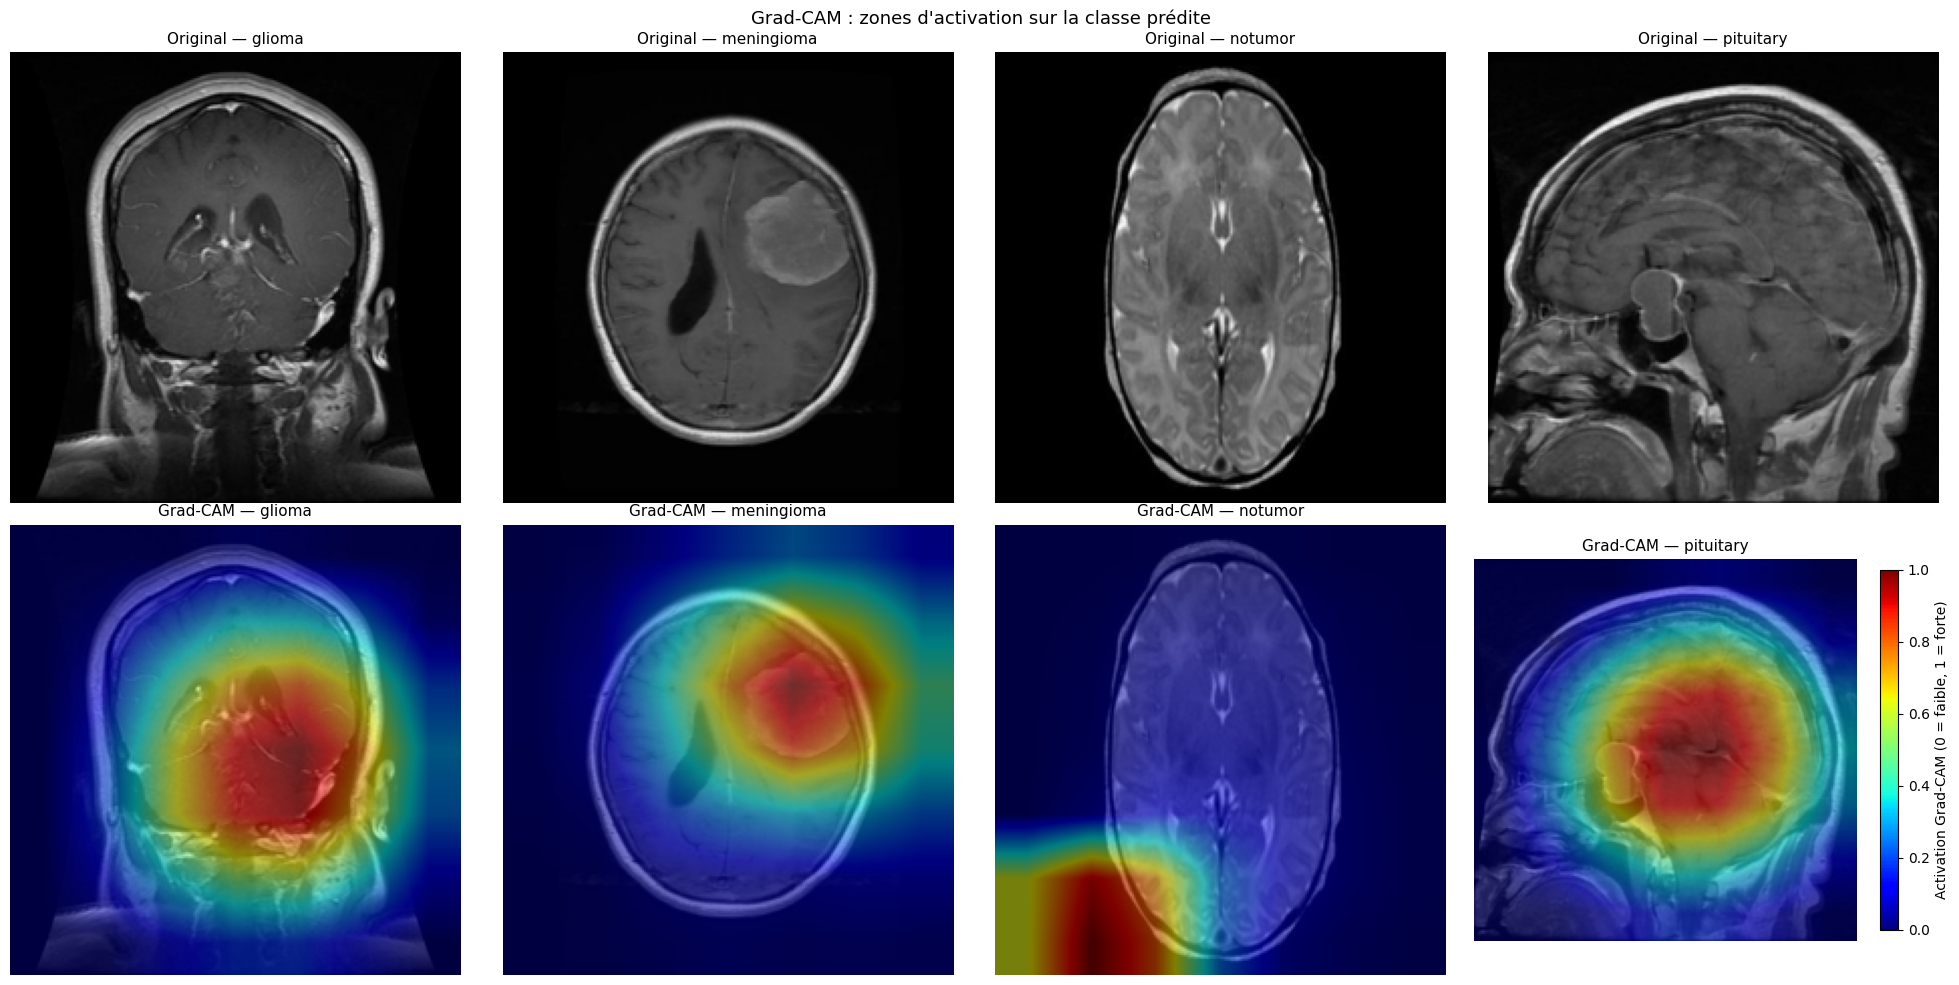

Sauvegardé gradcam_per_class.png


In [69]:
clinical_neutral = torch.tensor([0.5], dtype=torch.float32).to(device).unsqueeze(0)
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(20, 10))

for col, cls in enumerate(CLASSES):
    img_tensor = example_images[cls]
    true_idx   = CLASSES.index(cls)

    cam = gradcam.compute(img_tensor.clone(), clinical_neutral, true_idx)
    orig, overlay = overlay_cam(example_paths[cls], cam)

    axes[0, col].imshow(orig)
    axes[0, col].set_title(f"Original — {cls}", fontsize=11)
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay)
    axes[1, col].set_title(f"Grad-CAM — {cls}", fontsize=11)
    axes[1, col].axis("off")

plt.suptitle("Grad-CAM : zones d'activation sur la classe prédite", fontsize=13)
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = cm.ScalarMappable(cmap="jet", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes[1, -1], shrink=0.8, location="right", label="Activation Grad-CAM (0 = faible, 1 = forte)")
plt.tight_layout()
plt.savefig(f"{SAVEDIR}/gradcam_per_class.png", dpi=150)
plt.show()
print("Sauvegardé gradcam_per_class.png")

### Résumé des figures produites

| Fichier | Contenu |
|---|---|
| `runs_gradcam/gradcam_per_class.png` | Grad-CAM BNN sur une image représentative par classe |
| `runs_gradcam/gradcam_cnn_vs_bnn.png` | Comparaison CNN baseline (ligne 2) vs BNN multimodal (ligne 3) |
| `runs_gradcam/gradcam_uncertainty.png` | Grad-CAM moyen + σ spatial sur 50 passes MC |

### Comparaison Grad-CAM : CNN baseline vs BNN multimodal

CNN baseline chargé — epoch 8, AUC=0.999


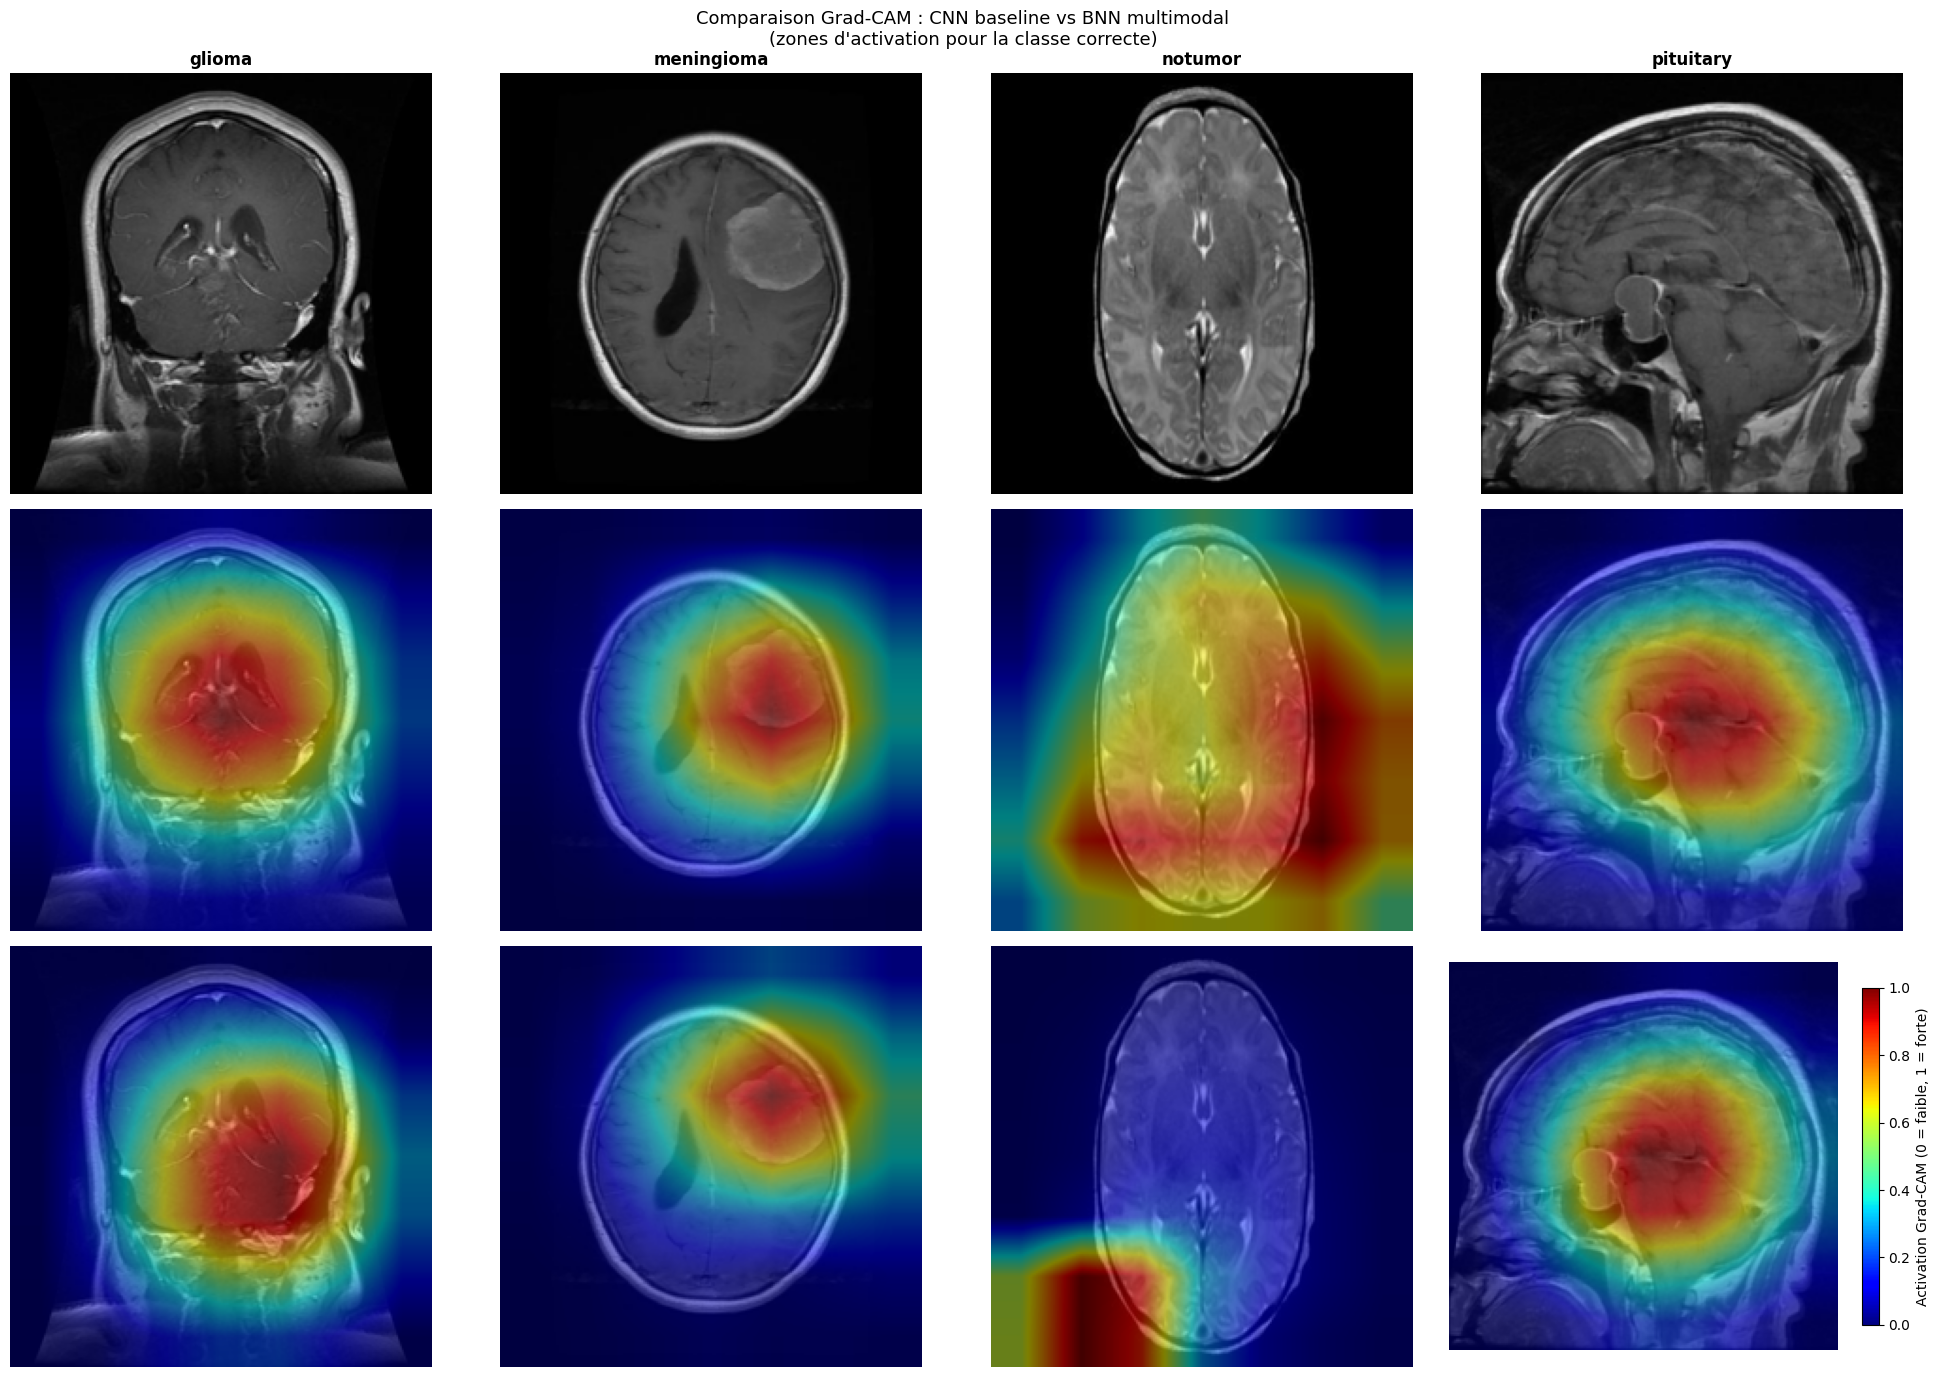

✓ Sauvegardé : gradcam_cnn_vs_bnn.png


In [73]:
CNN_CKPT = "runs_cnn_baseline/best_final.pt"

cnn_baseline = models.resnet18(weights="IMAGENET1K_V1")
cnn_baseline.fc = nn.Sequential(
    nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, NUM_CLASSES)
)
ckpt_cnn = torch.load(CNN_CKPT, map_location=device, weights_only=False)
cnn_baseline.load_state_dict(ckpt_cnn["model_state"])
cnn_baseline = cnn_baseline.to(device)
print(f"CNN baseline chargé — epoch {ckpt_cnn['epoch']}, AUC={ckpt_cnn['auc']:.3f}")

gradcam_cnn = GradCAM(cnn_baseline, cnn_baseline.layer4)


clinical_neutral = torch.tensor([[0.5]], dtype=torch.float32).to(device)

fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(20, 14))

for col, cls in enumerate(CLASSES):
    img_t    = example_images[cls]
    true_idx = CLASSES.index(cls)
    path     = example_paths[cls]

    cam_cnn  = gradcam_cnn.compute(img_t.clone(), None, true_idx)

    cam_bnn  = gradcam.compute(img_t.clone(), clinical_neutral, true_idx)

    orig, overlay_cnn = overlay_cam(path, cam_cnn)
    _,    overlay_bnn = overlay_cam(path, cam_bnn)

    axes[0, col].imshow(orig)
    axes[0, col].set_title(cls, fontsize=12, fontweight="bold")
    axes[0, col].axis("off")
    if col == 0:
        axes[0, col].set_ylabel("Original", fontsize=11, rotation=90, labelpad=40)

    axes[1, col].imshow(overlay_cnn)
    axes[1, col].axis("off")
    if col == 0:
        axes[1, col].set_ylabel("CNN seul", fontsize=11, rotation=90, labelpad=40)

    axes[2, col].imshow(overlay_bnn)
    axes[2, col].axis("off")
    if col == 0:
        axes[2, col].set_ylabel("BNN multimodal", fontsize=11, rotation=90, labelpad=40)

plt.suptitle("Comparaison Grad-CAM : CNN baseline vs BNN multimodal\n"
             "(zones d'activation pour la classe correcte)", fontsize=13)
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = cm.ScalarMappable(cmap="jet", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes[2, -1], shrink=0.8, location="right",
             label="Activation Grad-CAM (0 = faible, 1 = forte)")
plt.tight_layout()
plt.savefig(f"{SAVEDIR}/gradcam_cnn_vs_bnn.png", dpi=150)
plt.show()
print("✓ Sauvegardé : gradcam_cnn_vs_bnn.png")

### Incertitude sur l'attention - Grad-CAM moyen et écart-type BNN (50 passes MC)

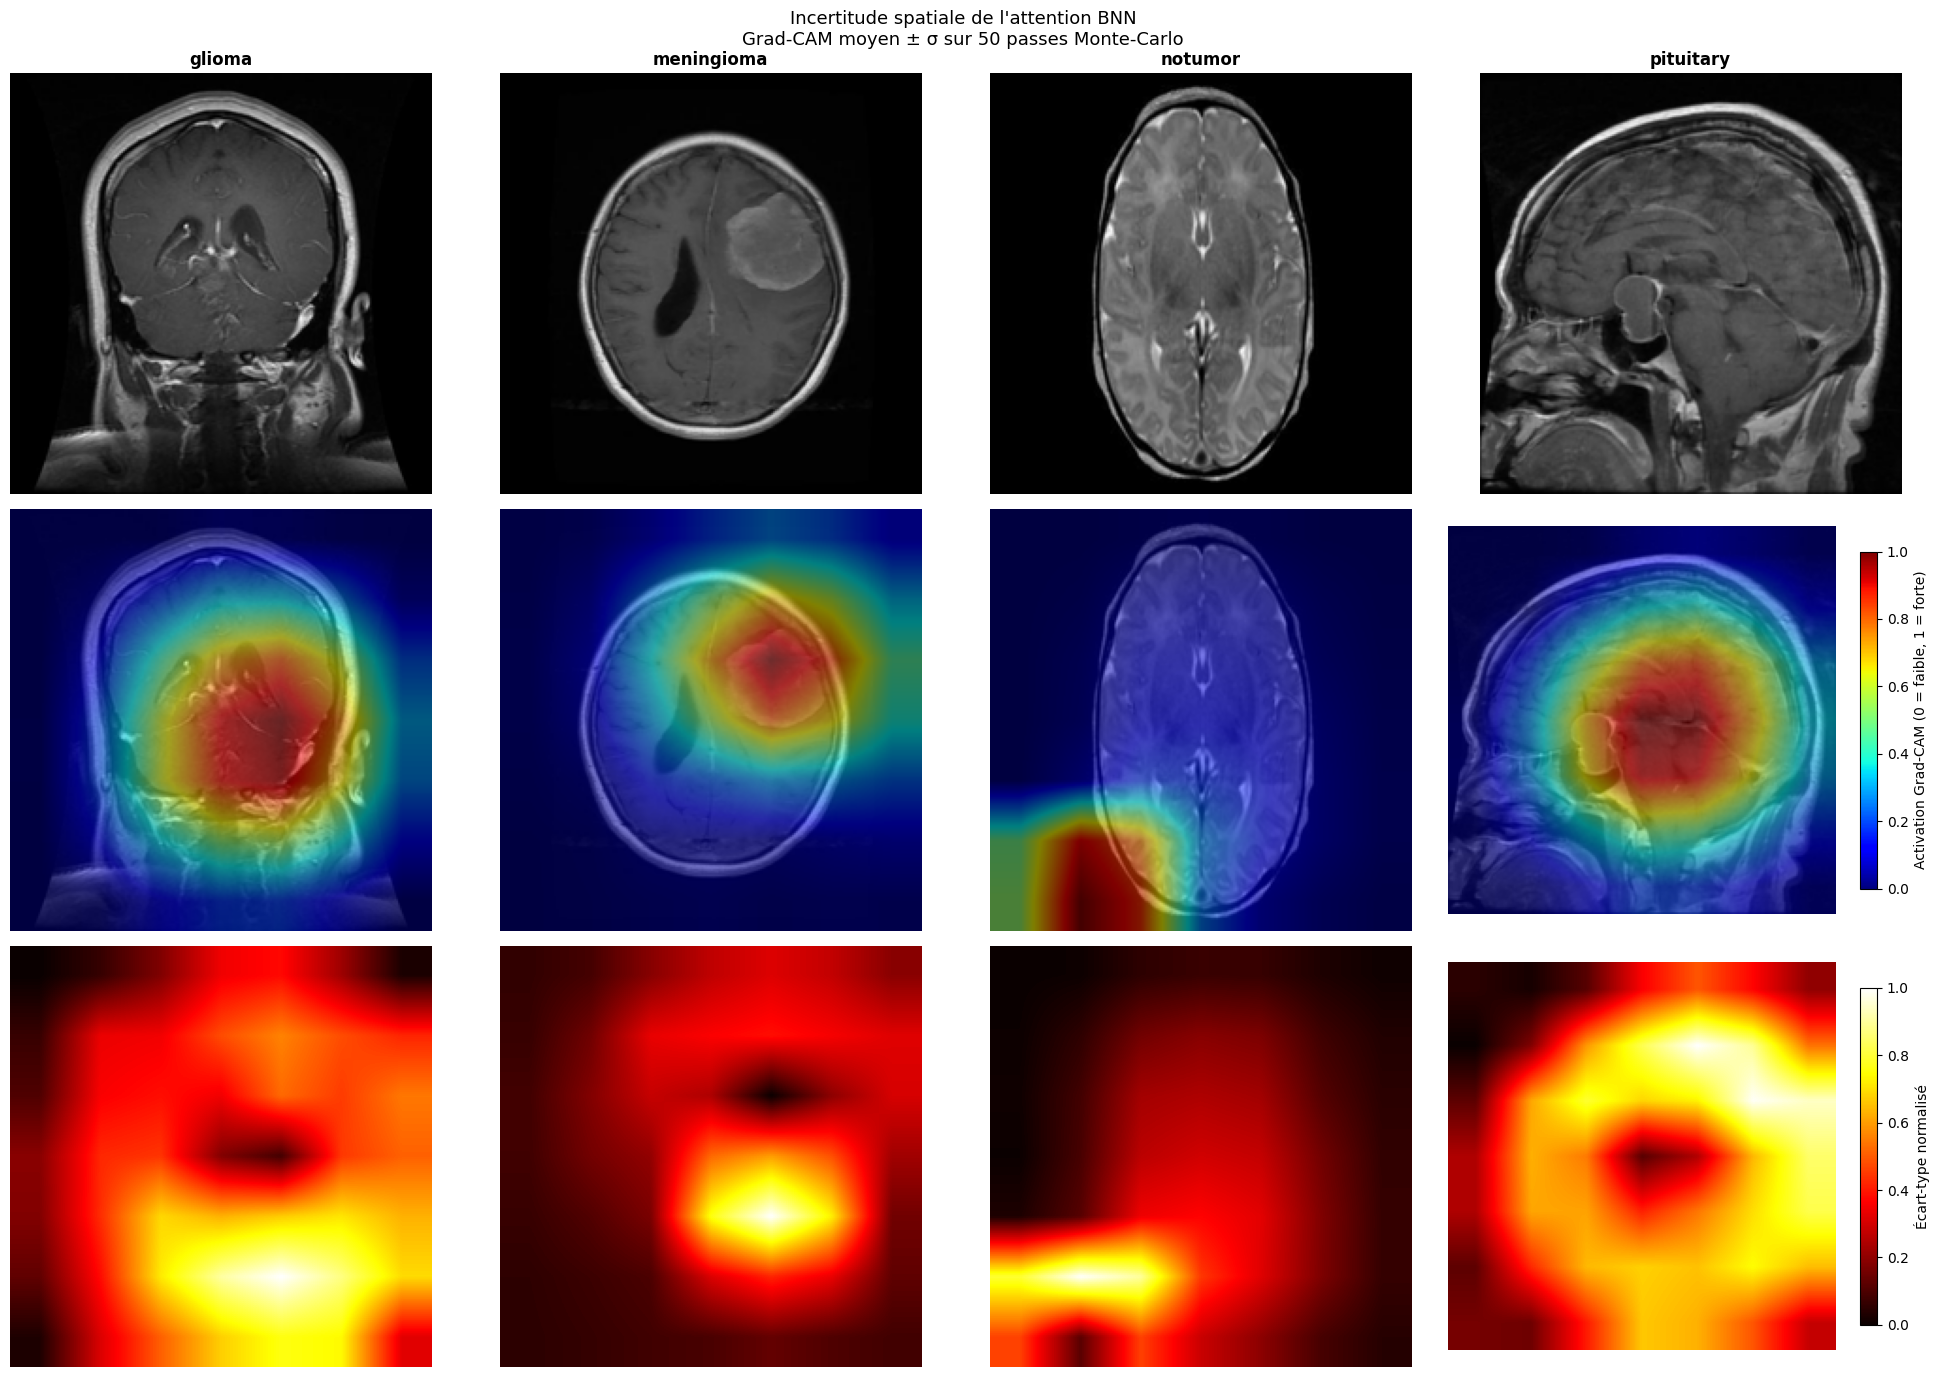

✓ Sauvegardé : gradcam_uncertainty.png


In [71]:
def compute_mc_gradcam(gradcam_obj, img_tensor, clinical_tensor, class_idx, n_passes=MC_PASSES):
    cams = []
    gradcam_obj.model.eval()
    for _ in range(n_passes):
        cam = gradcam_obj.compute(img_tensor.clone(), clinical_tensor, class_idx)
        cams.append(cam)
    cams = np.stack(cams, axis=0)
    return cams.mean(axis=0), cams.std(axis=0)


fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(20, 14))

for col, cls in enumerate(CLASSES):
    img_t    = example_images[cls]
    true_idx = CLASSES.index(cls)
    path     = example_paths[cls]

    mean_cam, std_cam = compute_mc_gradcam(
        gradcam, img_t, clinical_neutral, true_idx
    )
    orig, overlay_mean = overlay_cam(path, mean_cam)

    std_norm = (std_cam - std_cam.min()) / (std_cam.max() - std_cam.min() + 1e-8)
    std_resized = cv2.resize(std_norm, (IMGSIZE, IMGSIZE))

    axes[0, col].imshow(orig)
    axes[0, col].set_title(cls, fontsize=12, fontweight="bold")
    axes[0, col].axis("off")
    if col == 0:
        axes[0, col].set_ylabel("Original", fontsize=11, rotation=90, labelpad=40)

    axes[1, col].imshow(overlay_mean)
    axes[1, col].axis("off")
    if col == 0:
        axes[1, col].set_ylabel(f"CAM moyen\n({MC_PASSES} passes MC)", fontsize=10, rotation=90, labelpad=40)

    im = axes[2, col].imshow(std_resized, cmap="hot", vmin=0, vmax=1)
    axes[2, col].axis("off")
    if col == 0:
        axes[2, col].set_ylabel("Incertitude\nd'attention (σ)", fontsize=10, rotation=90, labelpad=40)

    axes[2, col].set_xlabel(f"σ moyen = {std_cam.mean():.4f}", fontsize=9)

fig.colorbar(im, ax=axes[2, -1], shrink=0.8, location="right", label="Écart-type normalisé")

plt.suptitle(f"Incertitude spatiale de l'attention BNN\n"
             f"Grad-CAM moyen ± σ sur {MC_PASSES} passes Monte-Carlo", fontsize=13)
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = cm.ScalarMappable(cmap="jet", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes[1, -1], shrink=0.8, location="right", label="Activation Grad-CAM (0 = faible, 1 = forte)")
plt.tight_layout()
plt.savefig(f"{SAVEDIR}/gradcam_uncertainty.png", dpi=150)
plt.show()
print("✓ Sauvegardé : gradcam_uncertainty.png")

In [72]:
print("=" * 50)
print(f"Figures sauvegardées dans : {SAVEDIR}")
print("=" * 50)
figures = {
    "gradcam_per_class.png":   "Grad-CAM BNN — zones activées par classe",
    "gradcam_cnn_vs_bnn.png":  "Comparaison Grad-CAM : CNN baseline vs BNN",
    "gradcam_uncertainty.png": "Incertitude spatiale d'attention (σ sur 50 passes MC)",
}
for fname, desc in figures.items():
    path   = os.path.join(SAVEDIR, fname)
    exists = "✓" if os.path.exists(path) else "✗"
    print(f"  {exists}  {fname:<35} {desc}")

Figures sauvegardées dans : runs_gradcam
  ✓  gradcam_per_class.png               Grad-CAM BNN — zones activées par classe
  ✓  gradcam_cnn_vs_bnn.png              Comparaison Grad-CAM : CNN baseline vs BNN
  ✓  gradcam_uncertainty.png             Incertitude spatiale d'attention (σ sur 50 passes MC)
